In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [2]:
!pip install datasets


   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.1 kB ? eta -:--:--
   ---------------------------------------- 559.1/559.1 kB 644.7 kB/s  0:00:00
   ---------------------------------------- 0.0/796.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/796.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/796.8 kB ? eta -:--:--
   ------------- -------------------------- 262.1/796.8 kB ? eta -:--:--
   ------------- -------------------------- 262.1/796.8 kB ? eta -:--:--
   ------------------------- ------------ 524.3/796.8 kB 622.7 kB/s eta 0:00:01
   ------------------------- ------------ 524.3/796.8 kB 622.7 kB/s eta 0:00:01
   ----------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.1 which is incompatible.


In [3]:
from datasets import load_dataset

print("Datasets library is working!")

Datasets library is working!


In [4]:
from datasets import load_dataset

dataset = load_dataset(
    "Project-AgML/tomato_leaf_disease",
    streaming=True
)

print(dataset)

README.md:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

C:\Users\hp\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\datasets--Project-AgML--tomato_leaf_disease. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


IterableDatasetDict({
    train: IterableDataset({
        features: ['image', 'label'],
        num_shards: 1
    })
})


In [6]:
print(dataset["train"].features)


{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Leaf Mold', 'Septoria Leaf Spot', 'Spider Mites Two-spotted Spider Mite', 'Target Spot', 'Tomato Mosaic Virus', 'Tomato Yellow Leaf Curl Virus'])}


In [7]:
import matplotlib.pyplot as plt

samples = []

for i, item in enumerate(dataset["train"]):
    samples.append(item)
    if i == 4:
        break

print("Downloaded samples:", len(samples))


Downloaded samples: 5


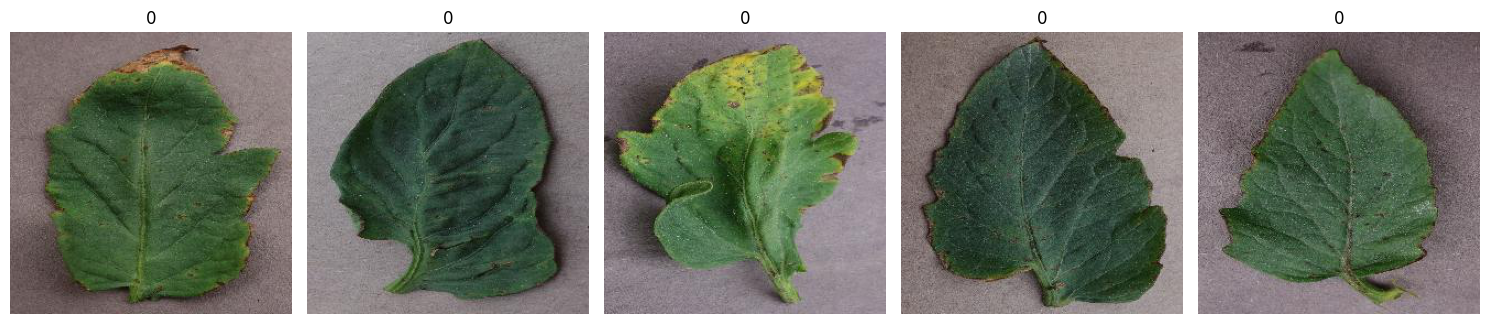

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, item in enumerate(samples):
    axes[i].imshow(item["image"])
    axes[i].set_title(item["label"])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [9]:

class_names = dataset["train"].features["label"].names

print(class_names)

['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Leaf Mold', 'Septoria Leaf Spot', 'Spider Mites Two-spotted Spider Mite', 'Target Spot', 'Tomato Mosaic Virus', 'Tomato Yellow Leaf Curl Virus']


In [10]:
for item in samples:
    print("Label:", item["label"])
    print("Disease:", class_names[item["label"]])
    print()

Label: 0
Disease: Bacterial Spot

Label: 0
Disease: Bacterial Spot

Label: 0
Disease: Bacterial Spot

Label: 0
Disease: Bacterial Spot

Label: 0
Disease: Bacterial Spot



In [11]:
class_names = dataset["train"].features["label"].names

for i, name in enumerate(class_names):
    print(i, "→", name)

0 → Bacterial Spot
1 → Early Blight
2 → Healthy
3 → Late Blight
4 → Leaf Mold
5 → Septoria Leaf Spot
6 → Spider Mites Two-spotted Spider Mite
7 → Target Spot
8 → Tomato Mosaic Virus
9 → Tomato Yellow Leaf Curl Virus


In [12]:
import os

base_dir = "dataset"
os.makedirs(base_dir, exist_ok=True)

print("Dataset folder created at:")
print(os.path.abspath(base_dir))

Dataset folder created at:
C:\Users\hp\dataset


In [1]:
import os

base_dir = os.path.join(os.path.expanduser("~"), "Desktop", "dataset")

print("Images will be saved here:")
print(base_dir)
print("Folder exists:", os.path.exists(base_dir))

Images will be saved here:
C:\Users\hp\Desktop\dataset
Folder exists: True


In [2]:
import os
from collections import defaultdict

# Location of your dataset folder
base_dir = os.path.join(os.path.expanduser("~"), "Desktop", "dataset")

# Disease/class names
class_names = dataset["train"].features["label"].names

# Number of images needed for each disease
images_per_class = 100

# Keep track of downloaded images
collected = defaultdict(int)

print("Starting download...")
print("Saving images to:", base_dir)

for item in dataset["train"]:
    
    label = item["label"]

    # Skip a class if we already have 100 images
    if collected[label] >= images_per_class:
        continue

    # Folder name
    class_name = class_names[label]
    folder_name = class_name.replace("/", "_").replace(" ", "_")

    class_dir = os.path.join(base_dir, folder_name)
    os.makedirs(class_dir, exist_ok=True)

    # Image number
    file_number = collected[label] + 1

    # File path
    file_path = os.path.join(
        class_dir,
        f"image_{file_number:03d}.jpg"
    )

    # Save image
    image = item["image"]
    image.convert("RGB").save(file_path, "JPEG", quality=85)

    collected[label] += 1

    # Show progress every 10 images
    if collected[label] % 10 == 0:
        print(f"{class_name}: {collected[label]}/100")

    # Stop when all 10 classes have 100 images
    if all(collected[i] >= images_per_class for i in range(len(class_names))):
        break

print("\nDOWNLOAD COMPLETE!")
print("-------------------------")

total = 0

for i, class_name in enumerate(class_names):
    print(f"{class_name}: {collected[i]} images")
    total += collected[i]

print("-------------------------")
print("Total images:", total)

NameError: name 'dataset' is not defined

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "Project-AgML/tomato_leaf_disease",
    streaming=True
)

print(dataset)


IterableDatasetDict({
    train: IterableDataset({
        features: ['image', 'label'],
        num_shards: 1
    })
})


In [4]:
class_names = dataset["train"].features["label"].names

print(class_names)

['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Leaf Mold', 'Septoria Leaf Spot', 'Spider Mites Two-spotted Spider Mite', 'Target Spot', 'Tomato Mosaic Virus', 'Tomato Yellow Leaf Curl Virus']


In [5]:
import os
from collections import defaultdict

# Location of your dataset folder
base_dir = os.path.join(os.path.expanduser("~"), "Desktop", "dataset")

# Disease/class names
class_names = dataset["train"].features["label"].names

# Number of images needed for each disease
images_per_class = 100

# Keep track of downloaded images
collected = defaultdict(int)

print("Starting download...")
print("Saving images to:", base_dir)

for item in dataset["train"]:
    
    label = item["label"]

    # Skip a class if we already have 100 images
    if collected[label] >= images_per_class:
        continue

    # Folder name
    class_name = class_names[label]
    folder_name = class_name.replace("/", "_").replace(" ", "_")

    class_dir = os.path.join(base_dir, folder_name)
    os.makedirs(class_dir, exist_ok=True)

    # Image number
    file_number = collected[label] + 1

    # File path
    file_path = os.path.join(
        class_dir,
        f"image_{file_number:03d}.jpg"
    )

    # Save image
    image = item["image"]
    image.convert("RGB").save(file_path, "JPEG", quality=85)

    collected[label] += 1

    # Show progress every 10 images
    if collected[label] % 10 == 0:
        print(f"{class_name}: {collected[label]}/100")

    # Stop when all 10 classes have 100 images
    if all(collected[i] >= images_per_class for i in range(len(class_names))):
        break

print("\nDOWNLOAD COMPLETE!")
print("-------------------------")

total = 0

for i, class_name in enumerate(class_names):
    print(f"{class_name}: {collected[i]} images")
    total += collected[i]

print("-------------------------")
print("Total images:", total)

Starting download...
Saving images to: C:\Users\hp\Desktop\dataset
Bacterial Spot: 10/100
Bacterial Spot: 20/100
Bacterial Spot: 30/100
Bacterial Spot: 40/100
Bacterial Spot: 50/100
Bacterial Spot: 60/100
Bacterial Spot: 70/100
Bacterial Spot: 80/100
Bacterial Spot: 90/100
Bacterial Spot: 100/100
Spider Mites Two-spotted Spider Mite: 10/100
Spider Mites Two-spotted Spider Mite: 20/100
Spider Mites Two-spotted Spider Mite: 30/100
Spider Mites Two-spotted Spider Mite: 40/100
Spider Mites Two-spotted Spider Mite: 50/100
Spider Mites Two-spotted Spider Mite: 60/100
Spider Mites Two-spotted Spider Mite: 70/100
Spider Mites Two-spotted Spider Mite: 80/100
Spider Mites Two-spotted Spider Mite: 90/100
Spider Mites Two-spotted Spider Mite: 100/100
Early Blight: 10/100
Early Blight: 20/100
Early Blight: 30/100
Early Blight: 40/100
Early Blight: 50/100
Early Blight: 60/100
Early Blight: 70/100
Early Blight: 80/100
Early Blight: 90/100
Early Blight: 100/100
Healthy: 10/100
Healthy: 20/100
Healthy:

In [6]:
import tensorflow as tf

base_dir = r"C:\Users\hp\Desktop\dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("Classes:")
print(class_names)

print("\nNumber of classes:", len(class_names))

Found 1000 files belonging to 10 classes.
Using 800 files for training.
Found 1000 files belonging to 10 classes.
Using 200 files for validation.
Classes:
['Bacterial_Spot', 'Early_Blight', 'Healthy', 'Late_Blight', 'Leaf_Mold', 'Septoria_Leaf_Spot', 'Spider_Mites_Two-spotted_Spider_Mite', 'Target_Spot', 'Tomato_Mosaic_Virus', 'Tomato_Yellow_Leaf_Curl_Virus']

Number of classes: 10


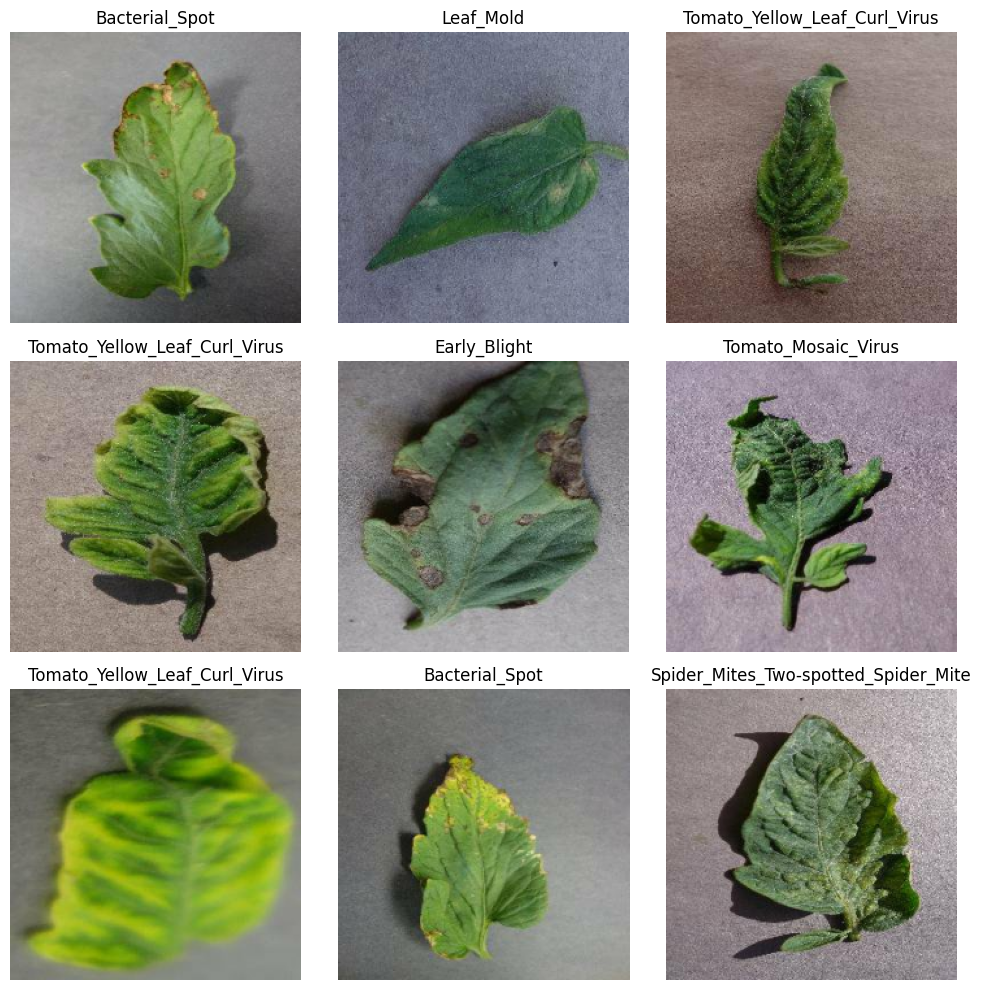

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from tensorflow.keras import layers

# Normalize pixel values from 0-255 to 0-1
normalization_layer = layers.Rescaling(1./255)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Apply normalization
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization and data augmentation setup complete!")

Normalization and data augmentation setup complete!


In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    
    # Input image
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 10 disease classes
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
import os
import tensorflow as tf

# Create folder to save the trained model
model_dir = os.path.join(base_dir, "models")
os.makedirs(model_dir, exist_ok=True)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(model_dir, "crop_disease_model.keras"),
        monitor="val_accuracy",
        save_best_only=True
    )
]

# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.1325 - loss: 2.4045 - val_accuracy: 0.1150 - val_loss: 2.3095
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.1825 - loss: 2.2035 - val_accuracy: 0.1350 - val_loss: 2.2722
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 811ms/step - accuracy: 0.2200 - loss: 2.1346 - val_accuracy: 0.2450 - val_loss: 2.1777
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 603ms/step - accuracy: 0.2725 - loss: 2.0142 - val_accuracy: 0.2350 - val_loss: 2.1181
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 615ms/step - accuracy: 0.3075 - loss: 1.9706 - val_accuracy: 0.3050 - val_loss: 2.0868
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 632ms/step - accuracy: 0.3938 - loss: 1.7502 - val_accuracy: 0.3700 - val_loss: 1.7912
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 650ms/step - accuracy: 0.4125 - loss: 1.6928 - val_accuracy: 0.4250 - val_loss: 1.6276
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 634ms/step - accuracy: 0.4913 - loss: 1.5009 - val_accuracy: 0.4200 - va

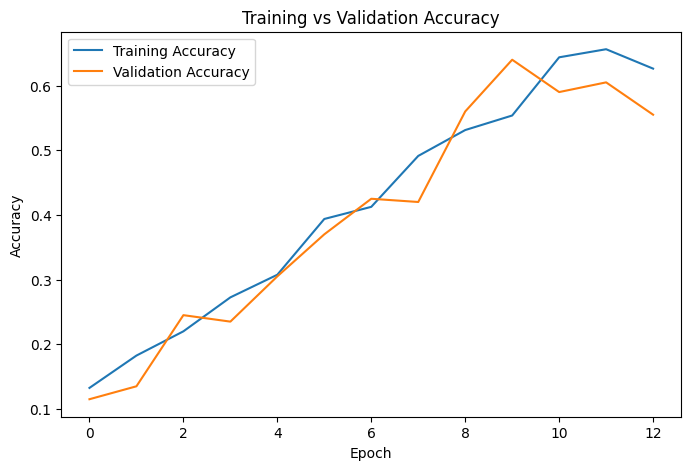

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

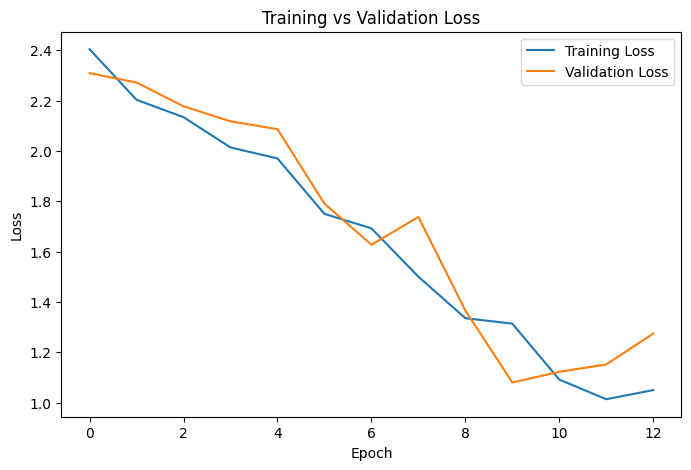

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [15]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("Validation Accuracy: {:.2f}%".format(accuracy * 100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.6400 - loss: 1.0802
Validation Loss: 1.0801689624786377
Validation Accuracy: 0.6399999856948853
Validation Accuracy: 64.00%


In [16]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                      precision    recall  f1-score   support

                      Bacterial_Spot       1.00      0.67      0.80        24
                        Early_Blight       0.57      0.24      0.33        17
                             Healthy       0.75      0.75      0.75        20
                         Late_Blight       0.80      0.44      0.57        18
                           Leaf_Mold       0.60      0.41      0.49        22
                  Septoria_Leaf_Spot       0.59      0.59      0.59        22
Spider_Mites_Two-spotted_Spider_Mite       0.52      0.69      0.59        16
                         Target_Spot       0.62      0.85      0.72        27
                 Tomato_Mosaic_Virus       0.61      0.87      0.71        23
       Tomato_Yellow_Leaf_Curl_Virus       0.47      0.82      0.60        11

                            accuracy                           0.64       200
                           macro avg       0.65      0.63     

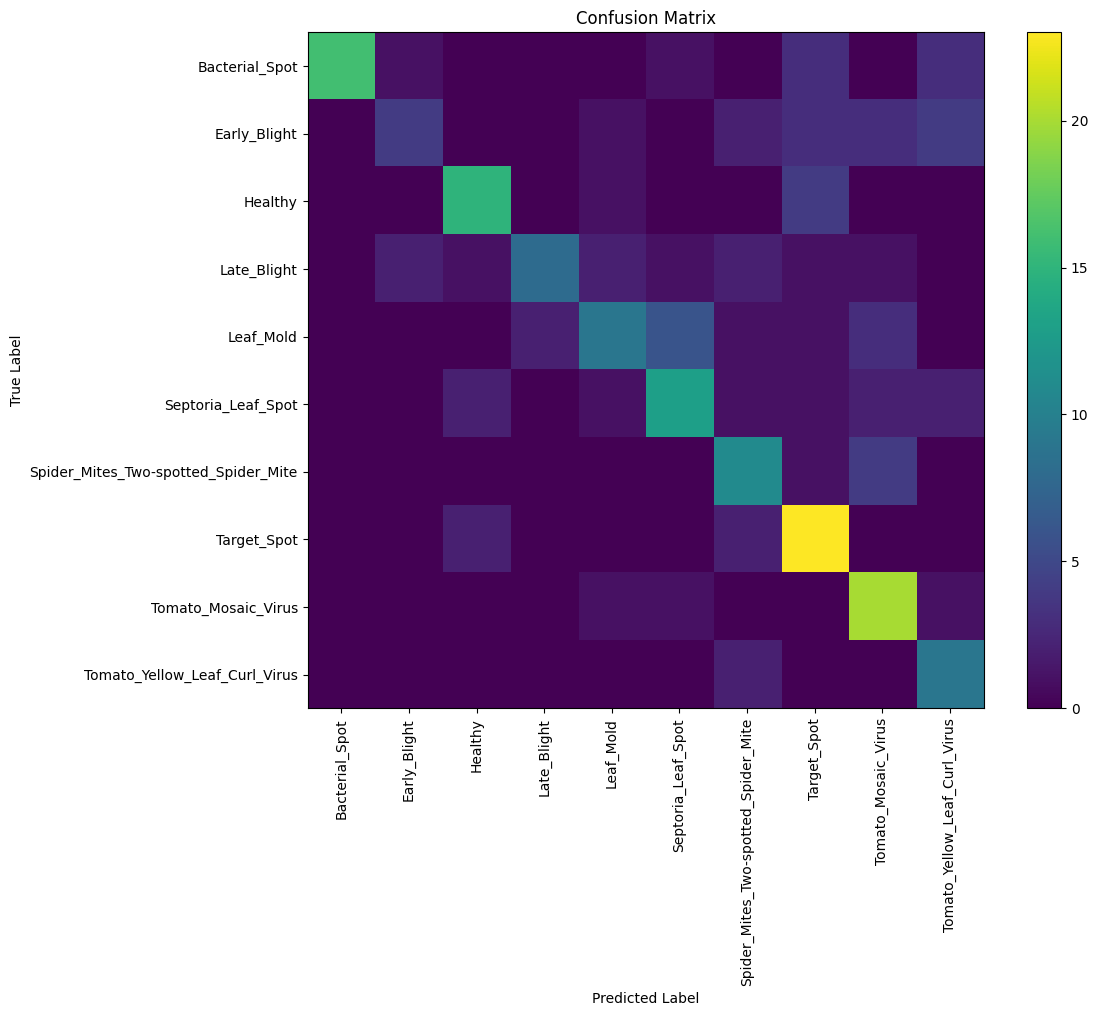

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

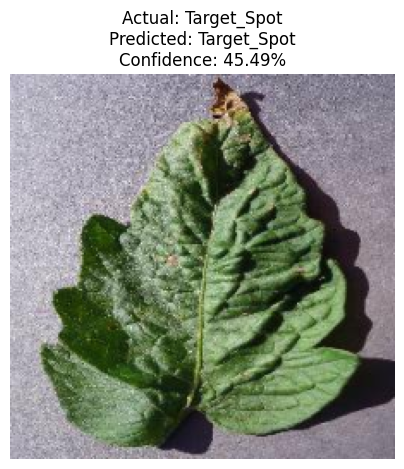

Actual disease: Target_Spot
Predicted disease: Target_Spot
Confidence: 45.49%


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Take one image from the validation dataset
for images, labels in validation_dataset.take(1):
    image = images[0]
    true_label = labels[0].numpy()

# Make prediction
prediction = model.predict(
    np.expand_dims(image.numpy(), axis=0),
    verbose=0
)

predicted_label = np.argmax(prediction[0])
confidence = prediction[0][predicted_label] * 100

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(image.numpy())
plt.title(
    f"Actual: {class_names[true_label]}\n"
    f"Predicted: {class_names[predicted_label]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print("Actual disease:", class_names[true_label])
print("Predicted disease:", class_names[predicted_label])
print("Confidence: {:.2f}%".format(confidence))

In [19]:
import tensorflow as tf
import numpy as np

def predict_disease(image_path):
    # Load image
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert image to array
    image_array = tf.keras.utils.img_to_array(image)

    # Normalize
    image_array = image_array / 255.0

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    predictions = model.predict(image_array, verbose=0)[0]

    # Get top 3 predictions
    top_indices = np.argsort(predictions)[-3:][::-1]

    print("Top 3 Predictions:")
    print("-------------------------")

    for index in top_indices:
        print(
            f"{class_names[index]}: "
            f"{predictions[index] * 100:.2f}%"
        )

    predicted_index = top_indices[0]

    print("\nPredicted Disease:")
    print(class_names[predicted_index])

    print(
        "Confidence: "
        f"{predictions[predicted_index] * 100:.2f}%"
    )

In [20]:
!pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.1
    Uninstalling protobuf-7.36.1:
      Successfully uninstalled protobuf-7.36.1


  You can safely remove it manually.


In [21]:
app_code = r'''
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os

# Page settings
st.set_page_config(
    page_title="Crop Disease Classifier",
    page_icon="🌱",
    layout="centered"
)

st.title("🌱 Crop Disease Classifier")
st.write("Upload a tomato leaf image to predict the disease.")

# Model path
base_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(base_dir, "models", "crop_disease_model.keras")

# Load model
model = tf.keras.models.load_model(model_path)

# Class names
class_names = [
    "Bacterial Spot",
    "Early Blight",
    "Healthy",
    "Late Blight",
    "Leaf Mold",
    "Septoria Leaf Spot",
    "Spider Mites Two-spotted Spider Mite",
    "Target Spot",
    "Tomato Mosaic Virus",
    "Tomato Yellow Leaf Curl Virus"
]

# Upload image
uploaded_file = st.file_uploader(
    "Choose a tomato leaf image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Leaf Image",
        use_container_width=True
    )

    # Prepare image
    image_resized = image.resize((224, 224))
    image_array = np.array(image_resized) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    predictions = model.predict(image_array, verbose=0)[0]

    top_indices = np.argsort(predictions)[-3:][::-1]

    predicted_index = top_indices[0]
    predicted_disease = class_names[predicted_index]
    confidence = predictions[predicted_index] * 100

    st.subheader("Prediction")

    st.success(f"🌿 Disease: {predicted_disease}")
    st.info(f"Confidence: {confidence:.2f}%")

    st.subheader("Top 3 Predictions")

    for index in top_indices:
        st.write(
            f"**{class_names[index]}** — "
            f"{predictions[index] * 100:.2f}%"
        )

st.warning(
    "This is an AI model prediction and should not be treated as a definitive agricultural diagnosis."
)
'''

with open(
    os.path.join(base_dir, "app.py"),
    "w",
    encoding="utf-8"
) as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [2]:
import os

base_dir = r"C:\Users\hp\Desktop\dataset"

requirements = """tensorflow
streamlit
numpy
pillow
matplotlib
scikit-learn
"""

with open(
    os.path.join(base_dir, "requirements.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [3]:
import os

base_dir = r"C:\Users\hp\Desktop\dataset"

gitignore = """# Dataset images
Bacterial Spot/
Early Blight/
Healthy/
Late Blight/
Leaf Mold/
Septoria Leaf Spot/
Spider Mites Two-spotted Spider Mite/
Target Spot/
Tomato Mosaic Virus/
Tomato Yellow Leaf Curl Virus/

# Python
__pycache__/
*.pyc

# Jupyter
.ipynb_checkpoints/

# Virtual environments
.venv/
venv/
"""

with open(
    os.path.join(base_dir, ".gitignore"),
    "w",
    encoding="utf-8"
) as f:
    f.write(gitignore)

print(".gitignore created successfully!")

.gitignore created successfully!


In [8]:
%%writefile C:\Users\hp\Desktop\dataset\README.md
# Crop Disease Classifier 🌱

This is a machine learning project that I made to identify diseases in tomato leaves from images.

The project uses a CNN (Convolutional Neural Network) trained on tomato leaf images. I also made a simple Streamlit web app where an image can be uploaded and the model predicts the disease.

## What it can detect

The model can classify 10 types of tomato leaves:

- Bacterial Spot
- Early Blight
- Healthy
- Late Blight
- Leaf Mold
- Septoria Leaf Spot
- Spider Mites Two-spotted Spider Mite
- Target Spot
- Tomato Mosaic Virus
- Tomato Yellow Leaf Curl Virus

## Technologies Used

- Python
- TensorFlow / Keras
- CNN
- NumPy
- Matplotlib
- Scikit-learn
- Streamlit
- Jupyter Notebook

## How I Built It

1. Collected the tomato leaf dataset
2. Created training and validation datasets
3. Resized the images to 224 × 224
4. Applied normalization and data augmentation
5. Built a CNN model
6. Trained the model
7. Evaluated the model using accuracy, classification report and confusion matrix
8. Created a prediction function
9. Built a Streamlit web app

## Model

The CNN contains:

- 3 convolutional layers
- Max pooling layers
- Dense layer
- Dropout
- Softmax output layer

Input image size: **224 × 224**

## Result

The model achieved around **64% validation accuracy** on the current dataset.

The application also shows the top 3 predictions with their confidence values.

## How to Run

Install the required packages:

```bash
pip install -r requirements.txt

## Dataset

I used the Tomato Leaf Disease dataset from Hugging Face.

## Note

This project was made for learning and demonstration purposes. The prediction should not be treated as a professional agricultural diagnosis.

## Future Improvements

- Train with more images
- Improve model accuracy
- Try transfer learning
- Add more crop diseases
- Add treatment information


Overwriting C:\Users\hp\Desktop\dataset\README.md
